In [1]:
import os
import h5py
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import yaml
import optax

In [2]:
import sys
sys.path.append('/Users/mariana/Documents/projects/Huawei/survan')

from lambda_cox import LambdaSA
from baseline_cox import SA
from utils import concordance_index, unroll, get_single_task_dataset, kaplan_meier, unroll_time

In [3]:
from functools import partial

In [4]:
def score(beta, xs):
    return -jnp.dot(xs, beta)

In [34]:
config_path = '../configs/config_aids.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

In [35]:
config['axis']

2

In [36]:
agent = SA(config, 42)
train_gen, test_gen = agent.get_train_test()

In [37]:
losses = agent.train(train_gen, test_gen)

In [38]:
train_loss, test_loss = losses

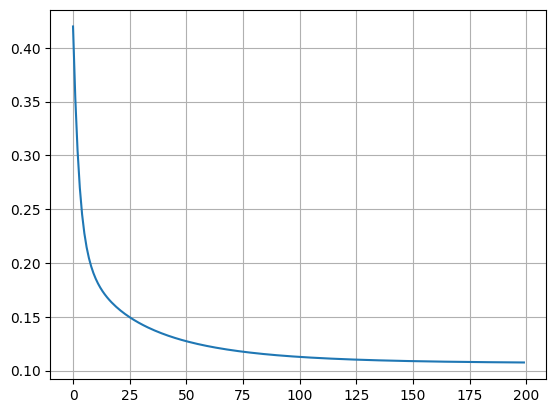

In [39]:
plt.plot(np.hstack(train_loss))
plt.grid()

In [40]:
agent.data['seqs'].shape

(467, 5, 5)

In [41]:
seqs = test_gen.X
ts = test_gen.ts
cs = test_gen.cs
ms = test_gen.mask

In [42]:
surv = agent.survival_curve(seqs)

In [62]:
%%time

num_exps = 5
sizes = [.5, .3, .2, .1, .05]

res2_is = np.zeros((num_exps, len(sizes)))
res2_lm = np.zeros((num_exps, len(sizes)))

res3_is = np.zeros((num_exps, len(sizes)))
res3_lm = np.zeros((num_exps, len(sizes)))

for fold in range(num_exps):
    for i, size in enumerate(sizes):
        
        print(".", end="")
        
        # Initial state.
        config['landmark'] = False
        model = SA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        ms = test_gen.mask
        
        _ = model.train(train_gen, test_gen)
        surv = model.survival_curve(seqs)
        surv_, ts_, cs_, ms_ = unroll_time(surv, ts, cs, ms, model.horizon)
        res2_is[fold, i] = model.integrated_brier_score(surv_, ts_, cs_, ms_)
        beta = model.state.params['cox_linear_model']['beta']
        seqs_ = seqs.reshape(-1, seqs.shape[-1])
        scores = score(beta, seqs[:,0])
        res3_is[fold, i] = concordance_index(scores, ts, cs)

        ms_is_ = jnp.copy(ms_)
        
        # Landmarking.
        config['landmark'] = True
        model = SA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        ms = test_gen.mask
        
        _ = model.train(train_gen, test_gen)
        surv = model.survival_curve(seqs)
        surv_, ts_, cs_, ms_ = unroll_time(surv, ts, cs, ms, model.horizon)
        res2_lm[fold, i] = model.integrated_brier_score(surv_, ts_, cs_, ms_is_)
        beta = model.state.params['cox_linear_model']['beta']
        seqs_ = seqs.reshape(-1, seqs.shape[-1])
        scores = score(beta, seqs[:,0])
        res3_lm[fold, i] = concordance_index(scores, ts, cs)
        
    print()

.....
.....
.....
.....
.....
CPU times: user 3min 53s, sys: 826 ms, total: 3min 54s
Wall time: 3min 55s


Text(0.5, 0, 'Test size proportion')

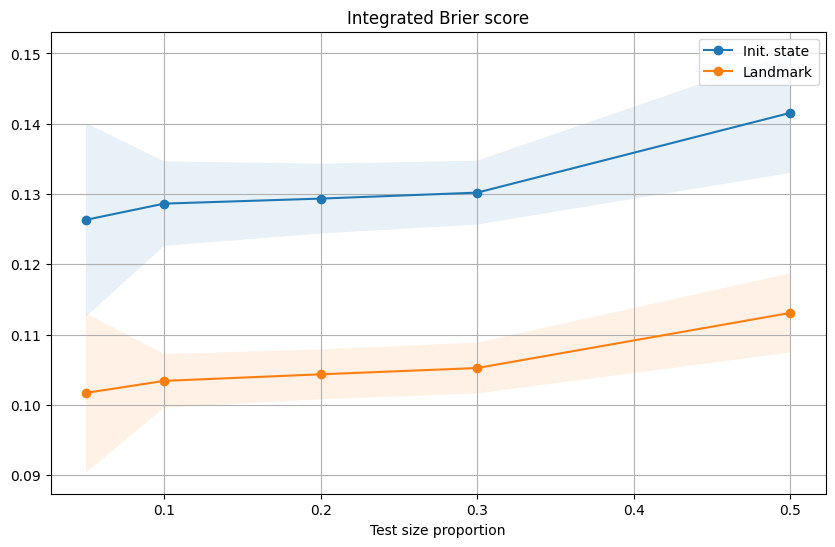

In [63]:
fig, ax = plt.subplots(figsize=(10, 6))

for res, label in ((res2_is, "Init. state"), (res2_lm, "Landmark")):
    mean = res.mean(axis=0)
    std = res.std(axis=0) / np.sqrt(num_exps)
    ax.plot(sizes, mean, marker="o", label=label)
    ax.fill_between(sizes, mean - std, mean + std, alpha=0.1)

ax.legend()
ax.grid()
ax.set_title("Integrated Brier score")
ax.set_xlabel("Test size proportion")

Text(0.5, 0, 'Number of patients')

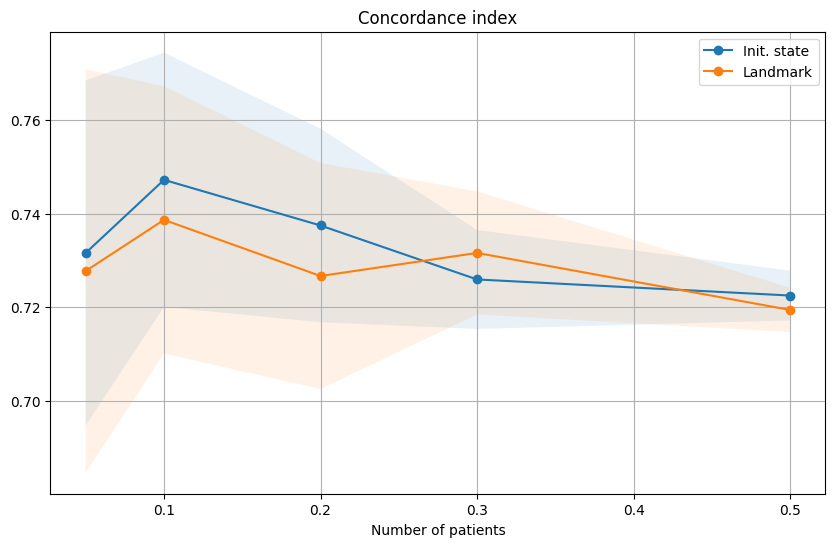

In [64]:
fig, ax = plt.subplots(figsize=(10, 6))

for res, label in ((res3_is, "Init. state"), (res3_lm, "Landmark")):
    mean = res.mean(axis=0)
    std = res.std(axis=0) / np.sqrt(num_exps)
    ax.plot(sizes, mean, marker="o", label=label)
    ax.fill_between(sizes, mean - std, mean + std, alpha=0.1)

ax.legend()
ax.grid()
ax.set_title("Concordance index")
ax.set_xlabel("Number of patients")